# Data filtering and visualization of FMI's Kuopio PV system

This notebook shows the qualitative analysis of the data and data filters.

Link to open data repository:
https://doi.org/10.57707/fmi-b2share.fbe73c1d7c144ce787db3785302dd1e1
 

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Add the folder path to sys.path
folder_path = os.path.abspath(os.path.join('..', 'helpers'))
sys.path.append(folder_path)

# Import the module
import filters
import preprocessing

# Add the folder path to sys.path
folder_path = os.path.abspath(os.path.join('..'))
sys.path.append(folder_path)

# Import the module
import config

matplotlib.rcParams['font.family'] = 'arial'
plt.rc('font', size=7)

# Path to data
DATA_PATH = os.path.join('Z:', 'Data', 'Data_by_FMI', 'Processed_data')

In [2]:
# Read data
data = pd.read_csv(os.path.join(DATA_PATH, 'FMI_Kuopio_PV.csv'), parse_dates=['utctime'], skiprows=67, delimiter=';')
data = data.rename(columns=config.col_name_dict_kuopio)
data = data[['utctime', 'power', 'pv_inv_out', 'T', 'poa', 'ghi', 'snow', 'wind', 'dataQC', 'viss_day']]
data

C:\Users\plkart\AppData\Local\Temp\ipykernel_16284\625209531.py:2: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(DATA_PATH, 'FMI_Kuopio_PV.csv'), parse_dates=['utctime'], skiprows=67, delimiter=';')


,utctime,power,pv_inv_out,T,poa,ghi,snow,wind,dataQC,viss_day
0,2016-09-22 00:00:00,NaN,NaN,8.5,NaN,-0.8,0.0,1.7,0.0,"[1, 7, 0, 0]"
1,2016-09-22 00:01:00,NaN,NaN,NaN,NaN,-0.7,0.0,NaN,0.0,"[1, 7, 0, 0]"
2,2016-09-22 00:02:00,NaN,NaN,NaN,NaN,-0.7,0.0,NaN,0.0,"[1, 7, 0, 0]"
3,2016-09-22 00:03:00,NaN,NaN,NaN,NaN,-0.8,0.0,NaN,0.0,"[1, 7, 0, 0]"
4,2016-09-22 00:04:00,NaN,NaN,NaN,NaN,-0.8,0.0,NaN,0.0,"[1, 7, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...
2774875,2021-12-31 23:55:00,NaN,NaN,-6.1,-0.7,-2.5,3.0,4.2,1.0,"[0, 0, 0, 0]"
2774876,2021-12-31 23:56:00,NaN,NaN,-6.1,-0.7,-2.4,3.0,4.4,1.0,"[0, 0, 0, 0]"
2774877,2021-12-31 23:57:00,NaN,NaN,-6.2,-0.7,-2.4,3.0,4.6,1.0,"[0, 0, 0, 0]"
2774878,2021-12-31 23:58:00,NaN,NaN,-6.2,-0.8,-2.5,3.0,4.7,1.0,"[0, 0, 0, 0]"


In [3]:
# Impute data to be minute-resolution
data = preprocessing.impute_columns(data, col_names=['T', 'wind'], resolutions=[10, 10])

# Drop the beginning of dataset where POA or power are NaN
data_nonans = data.dropna(subset=['poa', 'power'])
data = data[data.utctime >= data_nonans.utctime.iloc[0]]
data

,utctime,power,pv_inv_out,T,poa,ghi,snow,wind,dataQC,viss_day
262832,2017-03-23 12:32:00,25.1,36.4,4.4,613.5,433.3,1.0,5.9,0.0,"[1, 7, 0, 0]"
262833,2017-03-23 12:33:00,NaN,NaN,4.4,616.6,437.0,1.0,5.9,0.0,"[1, 7, 0, 0]"
262834,2017-03-23 12:34:00,NaN,NaN,4.4,616.2,437.4,1.0,5.9,0.0,"[1, 7, 0, 0]"
262835,2017-03-23 12:35:00,NaN,NaN,4.4,621.2,442.6,1.0,5.9,0.0,"[1, 7, 0, 0]"
262836,2017-03-23 12:36:00,NaN,NaN,4.4,634.8,457.5,1.0,5.9,0.0,"[1, 7, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...
2774875,2021-12-31 23:55:00,NaN,NaN,-6.1,-0.7,-2.5,3.0,4.2,1.0,"[0, 0, 0, 0]"
2774876,2021-12-31 23:56:00,NaN,NaN,-6.1,-0.7,-2.4,3.0,4.4,1.0,"[0, 0, 0, 0]"
2774877,2021-12-31 23:57:00,NaN,NaN,-6.2,-0.7,-2.4,3.0,4.6,1.0,"[0, 0, 0, 0]"
2774878,2021-12-31 23:58:00,NaN,NaN,-6.2,-0.8,-2.5,3.0,4.7,1.0,"[0, 0, 0, 0]"


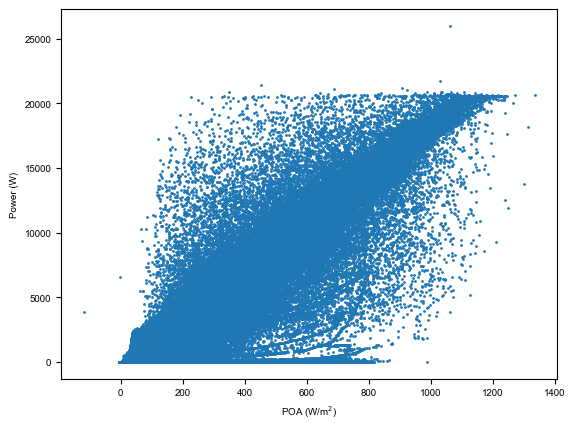

In [4]:
plt.scatter(data['poa'], data['power'], s=1)
plt.xlabel(r'POA (W/m$^2$)')
plt.ylabel('Power (W)')
plt.show()

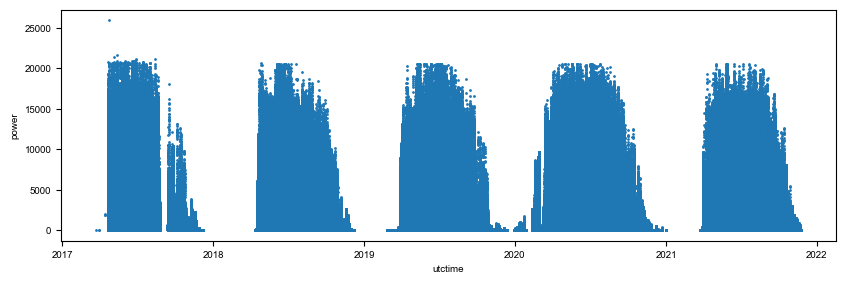

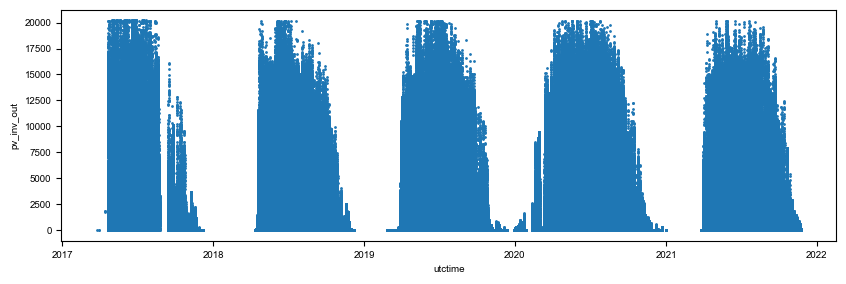

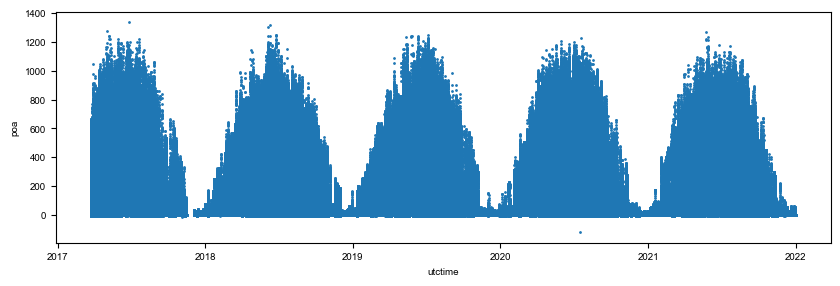

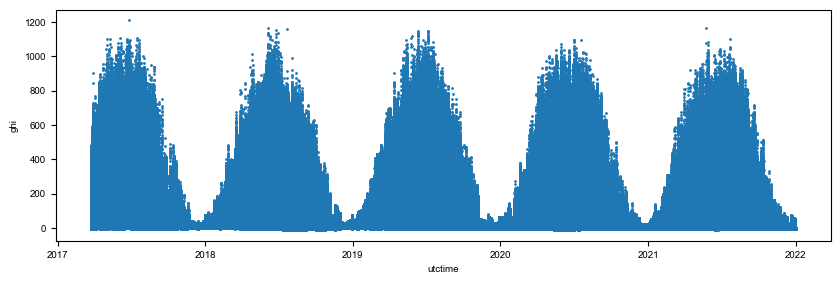

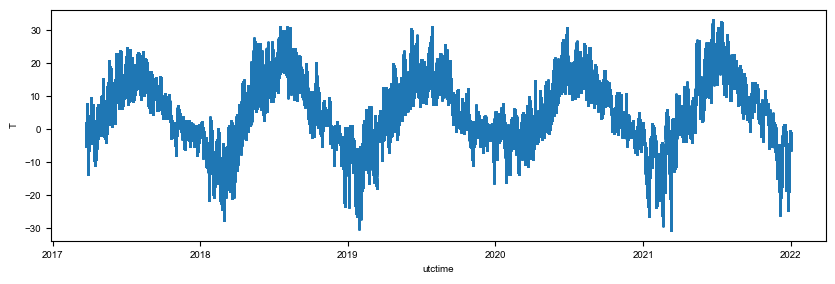

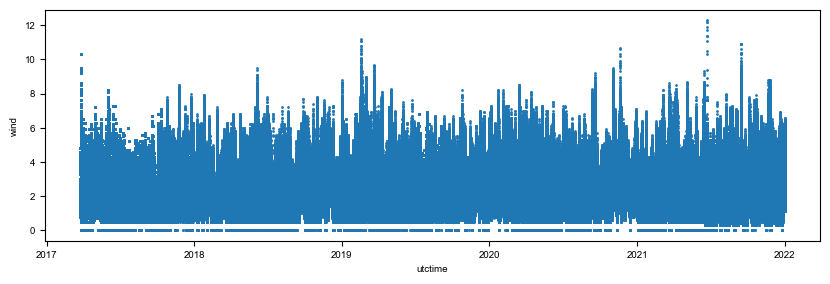

In [7]:
data.plot(x='utctime', y='power', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='pv_inv_out', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='poa', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='ghi', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='T', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='wind', kind='scatter', s=1, figsize=(10,3))
plt.show()

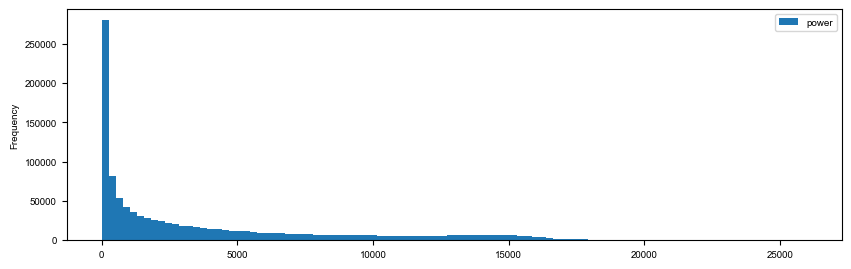

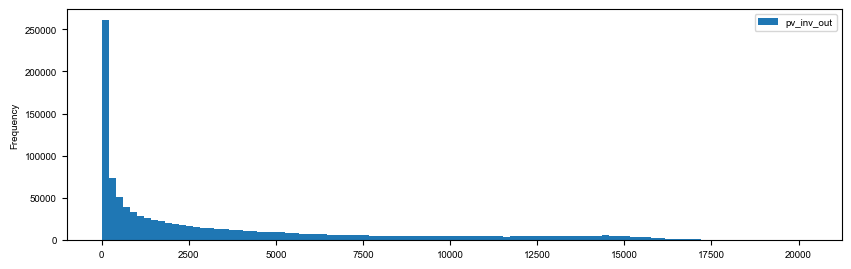

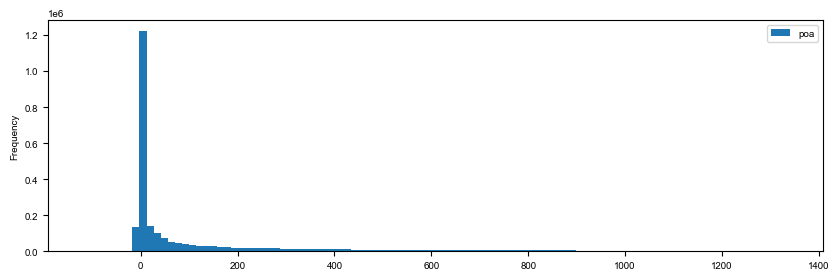

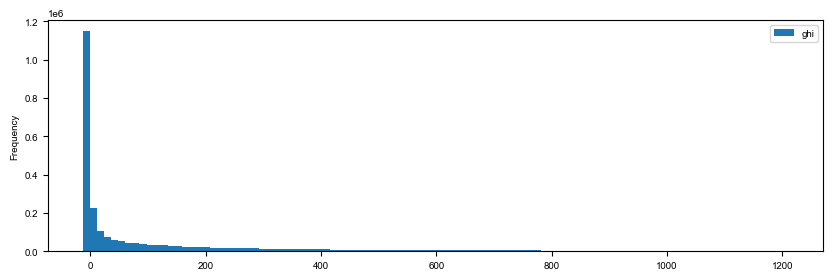

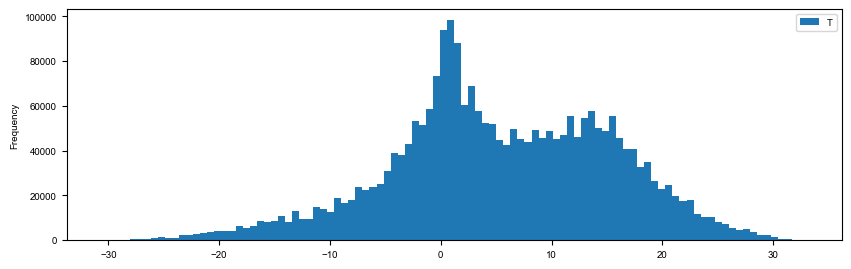

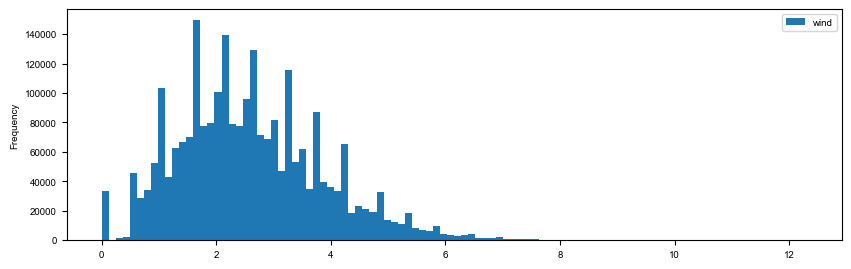

In [8]:
data.plot(x='utctime', y='power', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='pv_inv_out', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='poa', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='ghi', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='T', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='wind', kind='hist', bins=100, figsize=(10,3))
plt.show()

## Initial filtering

First, let's apply nighttime filter, IEC threhold filters, and quality control (QC) filter by Karhu et al. Additionally, since the powers seem to be clipped over 20 kW, let's apply a power threhold filter at 20 kW (rated power is 20.28 kWp).

In [9]:
data_day = data[filters.daytime(data)]

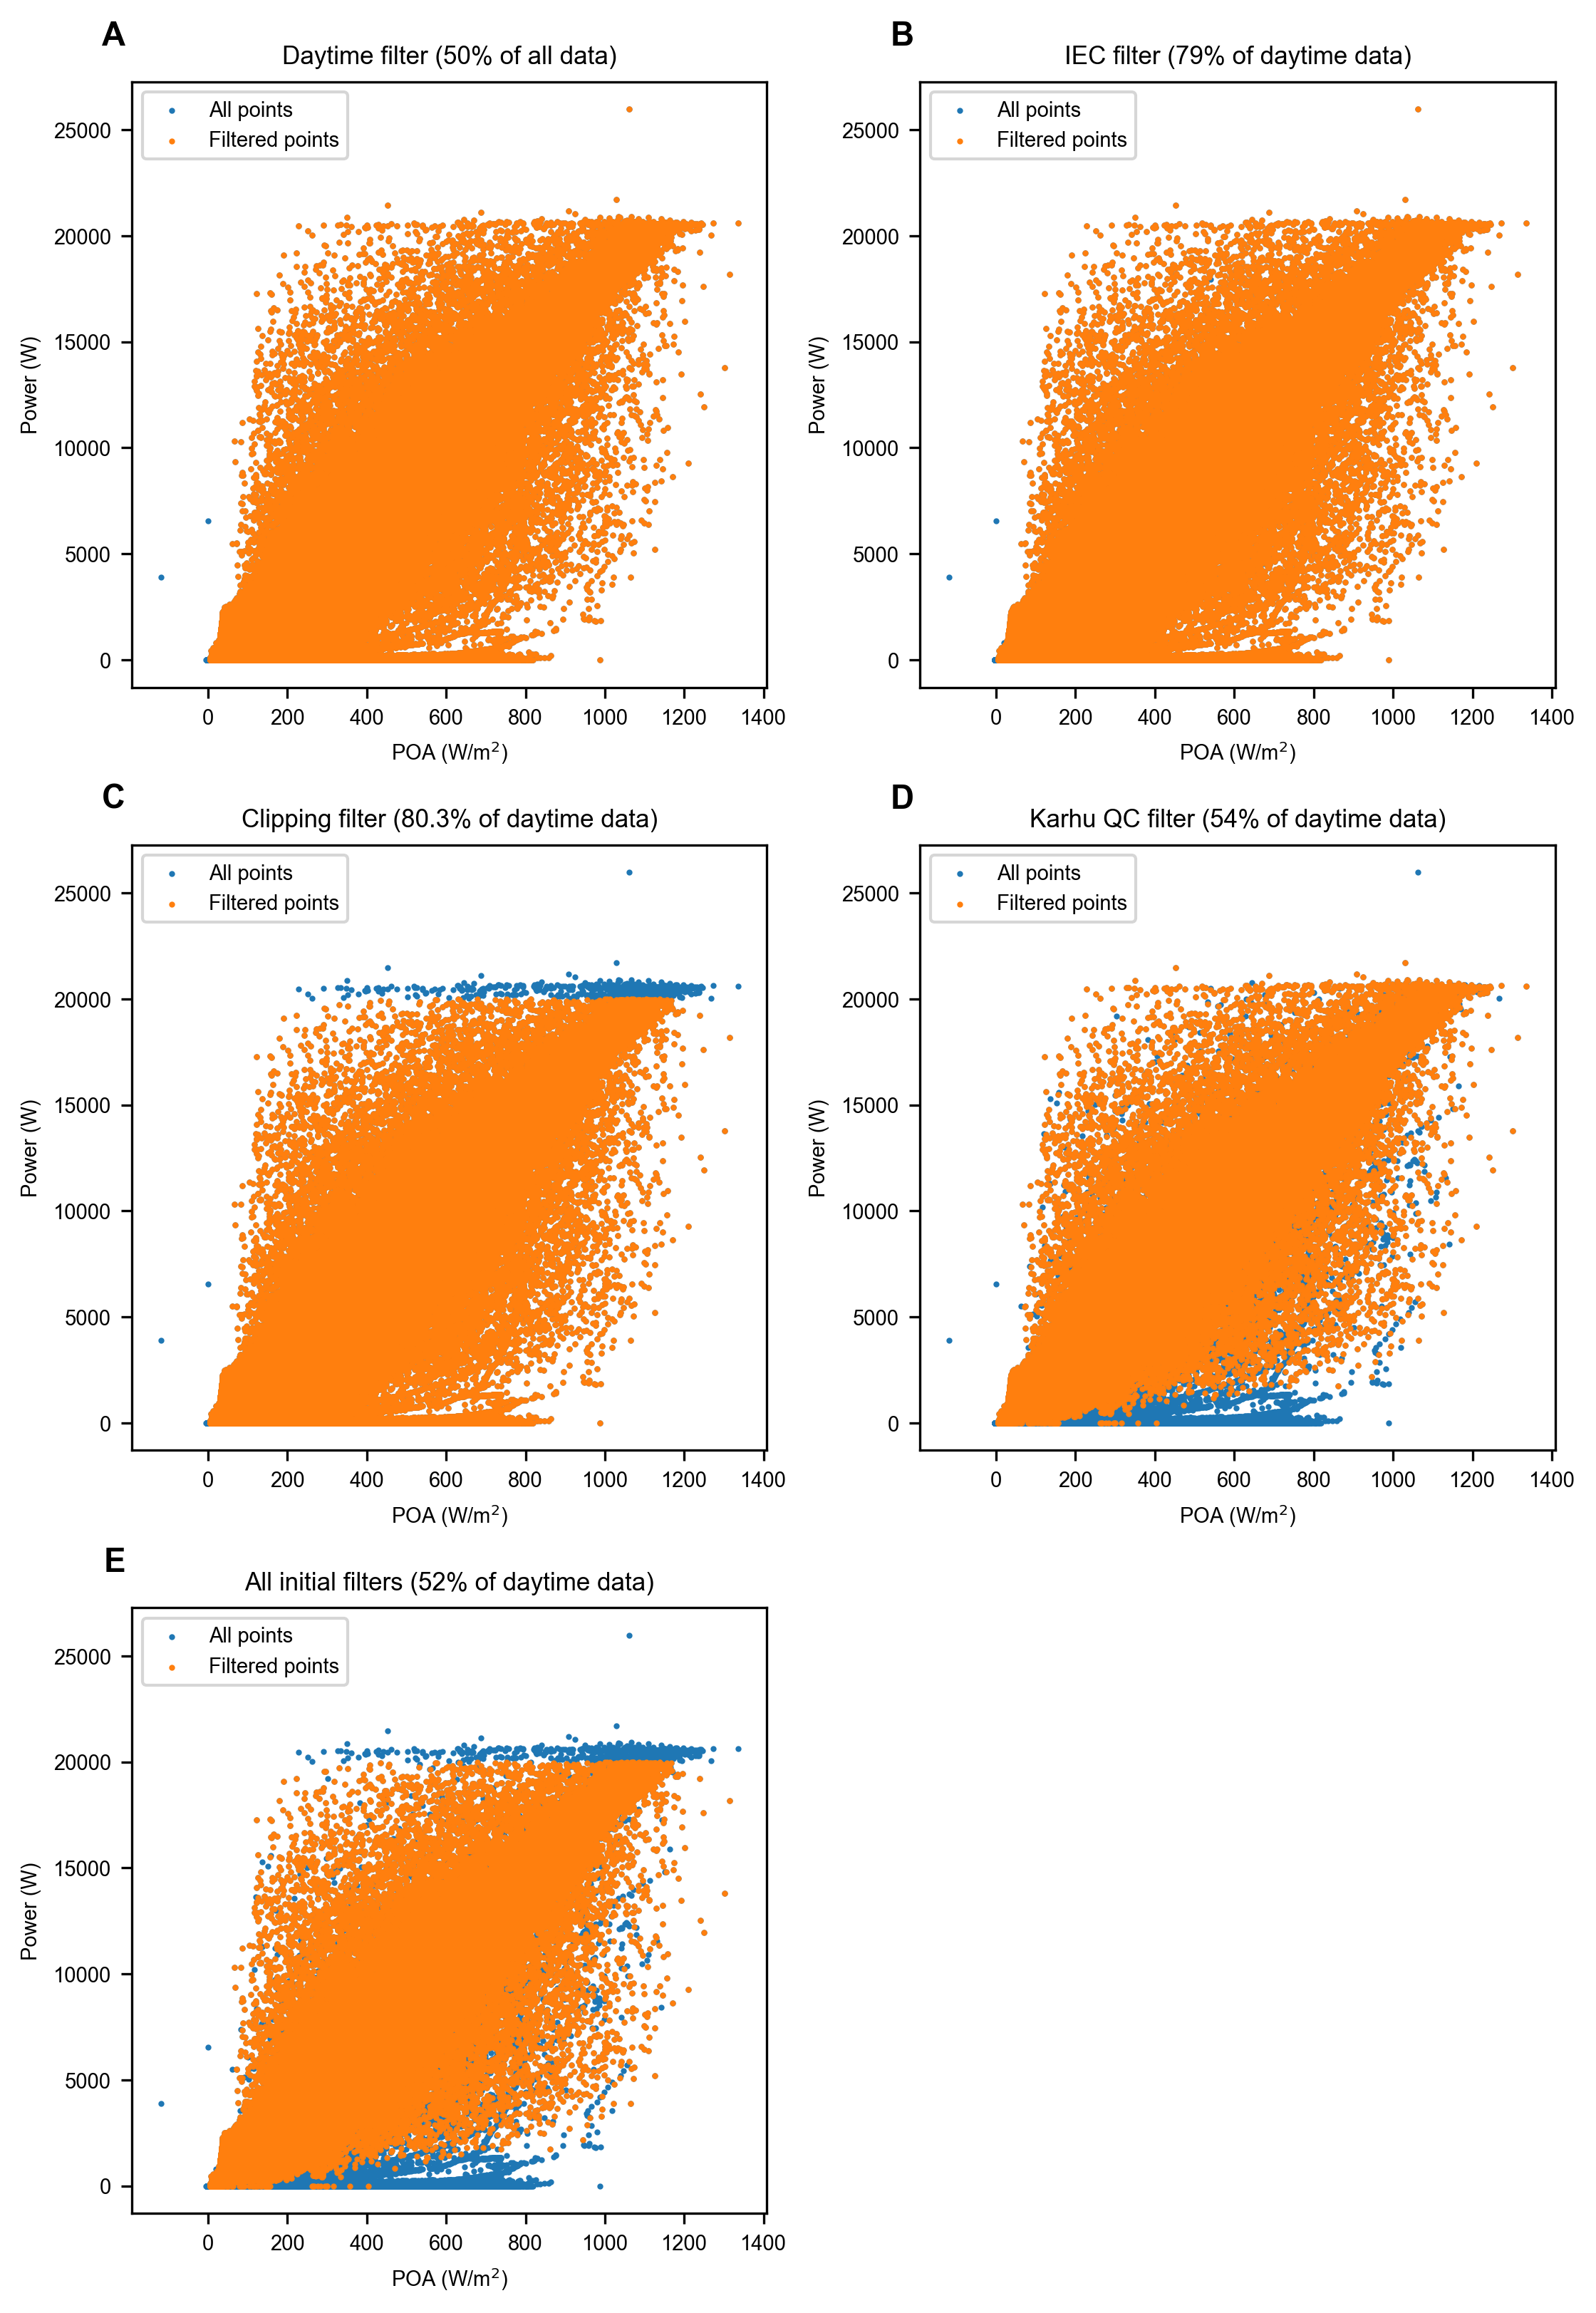

In [10]:
fig, ((ax0, ax1), (ax2, ax3), (ax4, ax5)) = plt.subplots(3, 2, figsize=(2244/300,3244/300), dpi=300)

ax0.scatter(data['poa'], data['power'], s=1, label='All points')
ax0.scatter(data_day['poa'], data_day['power'], s=1, label='Filtered points')
ax0.set_xlabel(r'POA (W/m$^2$)')
ax0.set_ylabel('Power (W)')
ax0.set_title(f'Daytime filter ({(len(data_day)/len(data))*100:.0f}% of all data)')
ax0.legend(loc='upper left')

ax1.scatter(data['poa'], data['power'], s=1, label='All points')
ax1.scatter(data_day[filters.IEC(data_day, 20280)]['poa'], data_day[filters.IEC(data_day, 20280)]['power'], s=1, label='Filtered points')
ax1.set_xlabel(r'POA (W/m$^2$)')
ax1.set_ylabel('Power (W)')
ax1.set_title(f'IEC filter ({(len(data_day[filters.IEC(data_day, 21000)])/len(data_day))*100:.0f}% of daytime data)')
ax1.legend(loc='upper left')

ax2.scatter(data['poa'], data['power'], s=1, label='All points')
ax2.scatter(data_day[filters.threshold(data_day, 'power', upper=20000)]['poa'], data_day[filters.threshold(data_day, 'power', upper=20000)]['power'], s=1, label='Filtered points')
ax2.set_xlabel(r'POA (W/m$^2$)')
ax2.set_ylabel('Power (W)')
ax2.set_title(f'Clipping filter ({(len(data_day[filters.threshold(data_day, 'power', upper=20000)])/len(data_day))*100:.1f}% of daytime data)')
ax2.legend(loc='upper left')

# Karhu filter
filter_mask = (data_day['dataQC'] == 1) & (data_day['snow'] == 0) & (data_day['viss_day'] == '[0, 0, 0, 0]')
ax3.scatter(data['poa'], data['power'], s=1, label='All points')
ax3.scatter(data_day[filter_mask]['poa'], data_day[filter_mask]['power'], s=1, label='Filtered points')
ax3.set_xlabel(r'POA (W/m$^2$)')
ax3.set_ylabel('Power (W)')
ax3.set_title(f'Karhu QC filter ({(len(data_day[filter_mask])/len(data_day))*100:.0f}% of daytime data)')
ax3.legend(loc='upper left')

# All filters
all_filter_mask = filters.IEC(data_day, 20280) & filters.threshold(data_day, 'power', upper=20000) & filter_mask
ax4.scatter(data['poa'], data['power'], s=1, label='All points')
ax4.scatter(data_day[all_filter_mask]['poa'], data_day[all_filter_mask]['power'], s=1, label='Filtered points')
ax4.set_xlabel(r'POA (W/m$^2$)')
ax4.set_ylabel('Power (W)')
ax4.set_title(f'All initial filters ({(len(data_day[all_filter_mask])/len(data_day))*100:.0f}% of daytime data)')
ax4.legend(loc='upper left')

ax5.remove()

for a, letter in list(zip([ax0, ax1, ax2, ax3, ax4], 
                        ['A', 'B', 'C', 'D', 'E'])):
    x0, xmax = a.set_xlim()
    y0, ymax = a.set_ylim()
    data_width = xmax - x0
    data_height = ymax - y0
    a.text(x0-(0.01*data_width), (y0 + 1.05*data_height), letter, weight='bold', fontsize=11, va='bottom', ha='right')


plt.tight_layout()
save_figure_path = os.path.join('Z:', 'Ongoing_works', 'EUPVSEC_25', 'Manuscript', 'Figures', 'kuopio_initial_filters.jpeg')
plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
plt.show()


## Outlier filtering
After initial filtering, there remains some outlying power-irradiance values, which should be removed for better performance analysis.

In [11]:
filter_mask = filters.daytime(data) & filters.IEC(data, 20280) & filters.threshold(data, 'power', upper=20000) & \
              (data['dataQC'] == 1) & (data['snow'] == 0) & (data['viss_day'] == '[0, 0, 0, 0]')
data_filtered = data[filter_mask]

### $\pm$ 2sd around instantaneous PR
This was used e.g., in [1]

[1]  https://doi.org/10.1002/pip.3397

In [12]:

# Get mean and standard deviation of P/POA (which is basically the same as PR)
data_filtered['p/poa'] = data.power / data.poa
p_poa_mean = data_filtered['p/poa'].mean()
p_poa_sd = data_filtered['p/poa'].std()
p_poa_mask = (data_filtered['p/poa'] > p_poa_mean - 2*p_poa_sd) & (data_filtered['p/poa'] < p_poa_mean + 2*p_poa_sd)

C:\Users\plkart\AppData\Local\Temp\ipykernel_21460\1398006881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['p/poa'] = data.power / data.poa


Share of data after filtering: 0.942


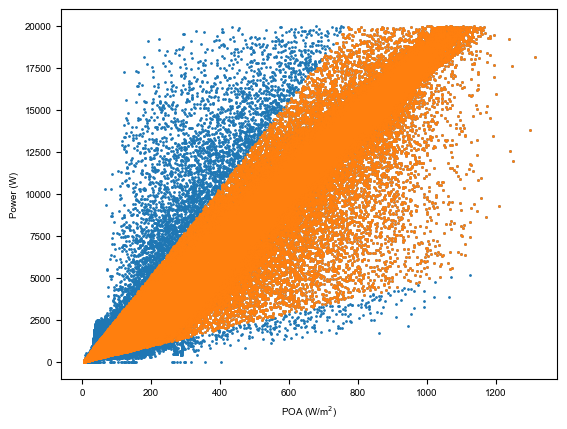

In [13]:
plt.scatter(data_filtered['poa'], data_filtered['power'], s=1, alpha=1)
plt.scatter(data_filtered[p_poa_mask]['poa'], data_filtered[p_poa_mask]['power'], s=1, alpha=1)
plt.xlabel(r'POA (W/m$^2$)')
plt.ylabel('Power (W)')

# Amount of data filtered
print('Share of data after filtering: {:.3f}'.format(len(data_filtered[p_poa_mask])/len(data_filtered)))


plt.show()

### Rolling window

Share of data after filtering compared with pre-filtered data: 0.954
Share of data after filtering compared with all daytime data: 0.500


C:\Users\plkart\AppData\Local\Temp\ipykernel_21460\3011970630.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\plkart\AppData\Local\Temp\ipykernel_21460\3011970630.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
C:\Users\plkart\AppData\Local\Temp\ipykernel_21460\3011970630.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
c:\Users\plkart\OneDrive - O365 Turun yliopisto\MatEng\codes_git2\pv-power-and-performance-modelling\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


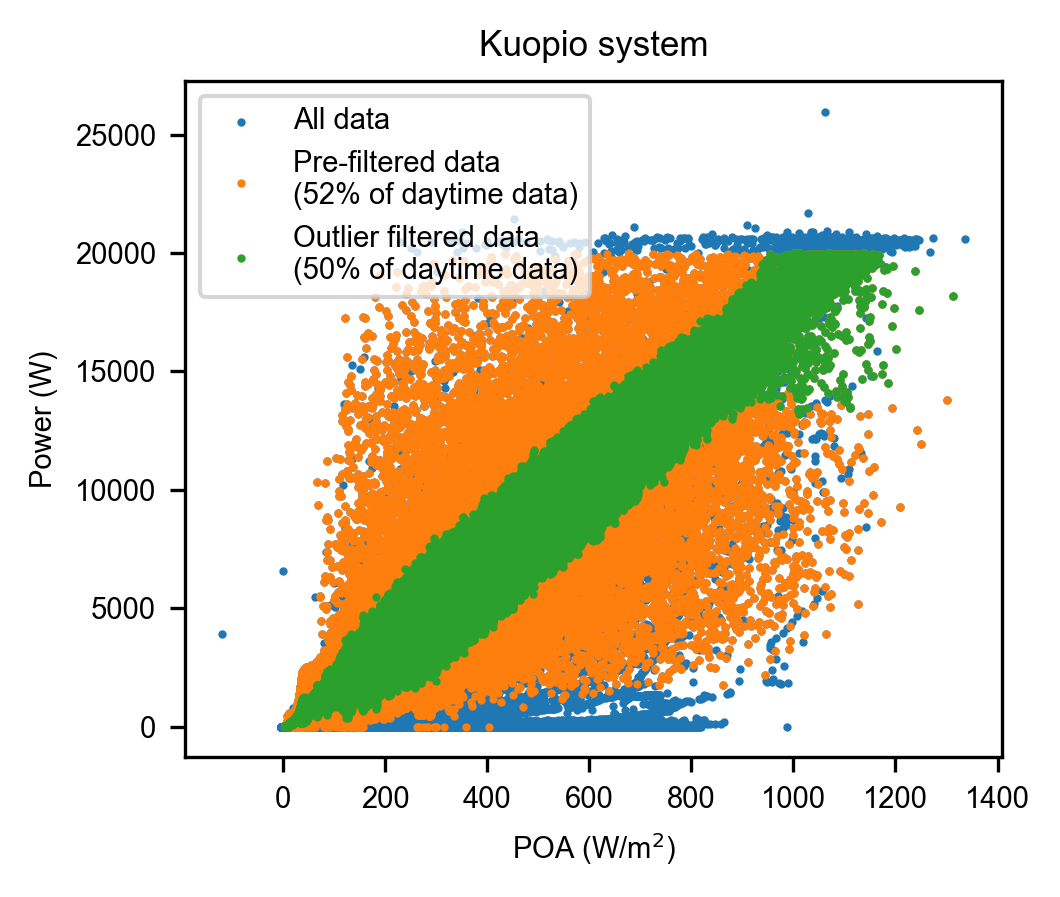

In [21]:
rolling_filter = filters.rolling_outlier_filter(data_filtered, 1000)

fig, ax = plt.subplots(1,1, figsize=(1063/300, 900/300), dpi=300)

ax.scatter(data['poa'], data['power'],  s=1, alpha=1, label='All data')
ax.scatter(data_filtered['poa'], data_filtered['power'], s=1, alpha=1, 
           label=f'Pre-filtered data\n({len(data_filtered)/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.scatter(data_filtered[rolling_filter]['poa'], data_filtered[rolling_filter]['power'], s=1, alpha=1,
           label=f'Outlier filtered data\n({len(data_filtered[rolling_filter])/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.set_xlabel(r'POA (W/m$^2$)')
ax.set_ylabel('Power (W)')
ax.legend()
ax.set_title('Kuopio system')

# Amount of data filtered
print('Share of data after filtering compared with pre-filtered data: {:.3f}'.format(len(data_filtered[rolling_filter])/len(data_filtered)))
print('Share of data after filtering compared with all daytime data: {:.3f}'.format(len(data_filtered[rolling_filter])/len(data[filters.daytime(data)])))

plt.tight_layout()
save_figure_path = os.path.join('Z:', 'Ongoing_works', 'EUPVSEC_25', 'Manuscript', 'Figures', 'kuopio_outlier_filter.jpeg')
plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)

plt.show()

## Clear-sky filtering

In [5]:
filter_mask = filters.daytime(data) & filters.IEC(data, 20280) & filters.threshold(data, 'power', upper=20000) & \
              (data['dataQC'] == 1) & (data['snow'] == 0) & (data['viss_day'] == '[0, 0, 0, 0]')
data_filtered = data[filter_mask]

Share of data after filtering compared with pre-filtered data: 0.396
Share of data after filtering compared with all daytime data: 0.207


C:\Users\plkart\AppData\Local\Temp\ipykernel_16284\1306306333.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\plkart\AppData\Local\Temp\ipykernel_16284\1306306333.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
C:\Users\plkart\AppData\Local\Temp\ipykernel_16284\1306306333.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
c:\Users\plkart\OneDrive - O365 Turun yliopisto\MatEng\codes_git2\pv-power-and-performance-modelling\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


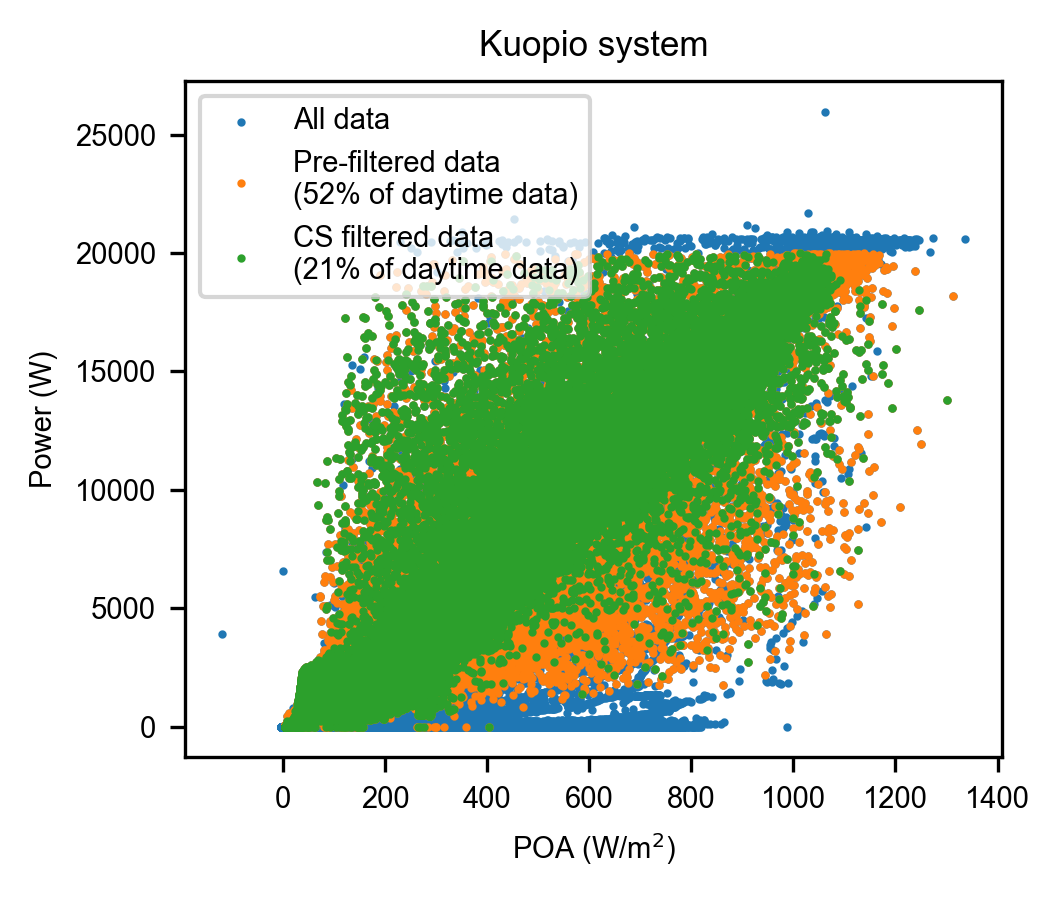

In [6]:
cs_filter = filters.clear_sky(data_filtered, latitude=config.latitude_kuopio, longitude=config.longitude_kuopio, 
                              altitude=config.elevation_kuopio)

fig, ax = plt.subplots(1,1, figsize=(1063/300, 900/300), dpi=300)

ax.scatter(data['poa'], data['power'],  s=1, alpha=1, label='All data')
ax.scatter(data_filtered['poa'], data_filtered['power'], s=1, alpha=1, 
           label=f'Pre-filtered data\n({len(data_filtered)/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.scatter(data_filtered[cs_filter]['poa'], data_filtered[cs_filter]['power'], s=1, alpha=1,
           label=f'CS filtered data\n({len(data_filtered[cs_filter])/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.set_xlabel(r'POA (W/m$^2$)')
ax.set_ylabel('Power (W)')
ax.legend()
ax.set_title('Kuopio system')
# Amount of data filtered
print('Share of data after filtering compared with pre-filtered data: {:.3f}'.format(len(data_filtered[cs_filter])/len(data_filtered)))
print('Share of data after filtering compared with all daytime data: {:.3f}'.format(len(data_filtered[cs_filter])/len(data[filters.daytime(data)])))

plt.tight_layout()
save_figure_path = os.path.join('Z:', 'Ongoing_works', 'EUPVSEC_25', 'Manuscript', 'Figures', 'kuopio_clearsky_filter.jpeg')
plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)

plt.show()